This notebook was made using Python version 3.10.20.

In [2]:
import matplotlib.pyplot as plt
import matplotlib.image as img
import spectral
import numpy as np
import spectral.io.envi as envi

#Helper functions:

def retrieve_picture(path, folder_name, file_number):
    data = envi.open(path+folder_name+'/capture/'+file_number)
    data_white = envi.open(path+folder_name+'/capture/WHITEREF_'+file_number)
    data_dark = envi.open(path+folder_name+'/capture/DARKREF_'+file_number)
    return data, data_white, data_dark

def references(path, folder_name, file_number):
    dark_ref = envi.open(path+folder_name+'/capture/DARKREF_'+file_number+'.hdr', path+folder_name+'/capture/DARKREF_'+file_number+'.raw')
    white_ref = envi.open(path+folder_name+'/capture/WHITEREF_'+file_number+'.hdr', path+folder_name+'/capture/WHITEREF_'+file_number+'.raw')
    data_ref = envi.open(path+folder_name+'/capture/'+file_number+'.hdr', path+folder_name+'/capture/'+file_number+'.raw')
    return data_ref, white_ref, dark_ref

def nparr(path, folder_name, file_number):
    data_ref, white_ref, dark_ref = references(path, folder_name, file_number)

    white_nparr = np.array(white_ref.load())
    dark_nparr = np.array(dark_ref.load())
    data_nparr = np.array(data_ref.load())

    corrected_nparr = np.divide(
    np.subtract(data_nparr, dark_nparr),
    np.subtract(white_nparr, dark_nparr))
    return corrected_nparr

def squeeze(x, y, path, folder_name, file_number):
    corrected_nparr = nparr(path, folder_name, file_number)

    pixel = corrected_nparr[
    y:y+1,
    x:x+1,
    :]

    return np.squeeze(pixel)

### Info

Sensor type in the Kitchen dataset: SPECIM IQ

Serial number: 190-1000103

Sensor ID: XSB32570209

Firmware: 2019.05.31.1

Used spectral bands: between 397.32 nm and 1003.58 nm (from visible violet to near-infrared)

The folder structure of the imaging data is the following:

<pre>
everyday_objects
|_kitchen
| |_basmatiriisi
|   |_capture
|     |_[nr].hdr
|       [nr].raw
|       DARKREF_[nr].hrd
|       DARKREF_[nr].raw
|       WHITEDARKREF_[nr].hrd
|       WHITEDARKREF_[nr].raw
|       WHITEREF_[nr].hrd
|       WHITEREF_[nr].raw
|     metadata
|     |_[nr].xml
|     results
|     |_REFLECTANCE_[nr].dat
|       REFLECTANCE_[nr].hdr
|       REFLECTANCE_[nr].png
|       RGBBACKGROUND_[nr].png
|       RGBSCENE_[nr].png
|       RGBVIEWFINDER_[nr].png
|     .validated
|     [nr].png
|     manifest.xml
|  ...
|_kitchenday2
</pre>

`[nr]` refers to the number associated with the specific capture. The number can be found, for example, in the name of the PNG file in the imaging folder.

This Python notebook has been made to demonstrate and aid the usage of hyperspectral (HS) images with Python. The HS material used in this notebook is the Kitchen dataset: it contains HS images, also called data cubes, of 23 light-colored substances found in a regular kitchen. The images have been captured with 204 spectral bands and have 512 $\times$ 512 px spatial resolution and 7 nm spectral resolution. The images also have ground truth annotations available. There are also 4 images with multiple different substances.

<br>

The images are called "data cubes", because the hyperspectral data has been combined to form a 3-dimensional object (x, y, $\lambda$). In this case, the images have 512 $\times$ 512 px spatial resolution, so the data cube is 512 pixels wide and 512 pixels tall (the x and y dimension). The different spectral bands form the third dimension ($\lambda$) of the cube, also called the "spectral dimension". Basically, in this case, the cube is 204 bands "deep".

<br>

Below is an example PNG image of a petridish filled with basmati rice on a black background.

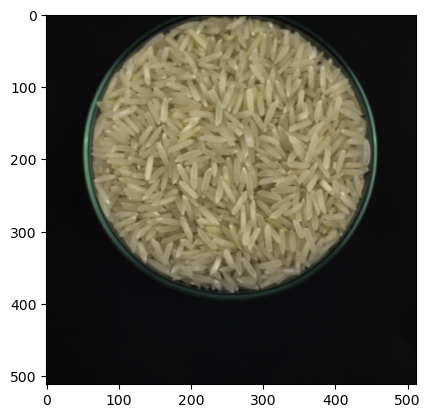

In [3]:
img = img.imread('/n/archive/labs/hsi-data/everyday_objects/kitchen/basmatiriisi/040.png')
plt.imshow(img)

Usually, the x- and y-dimensions of a HS image are portrayed like a normal photograph, while the $\lambda$-dimension is portrayed as a 2D-graph showing the reflectance of a single pixel. An example below (OBS! The graph changes slightly every time the code is run, since it chooses a random picture every time.):

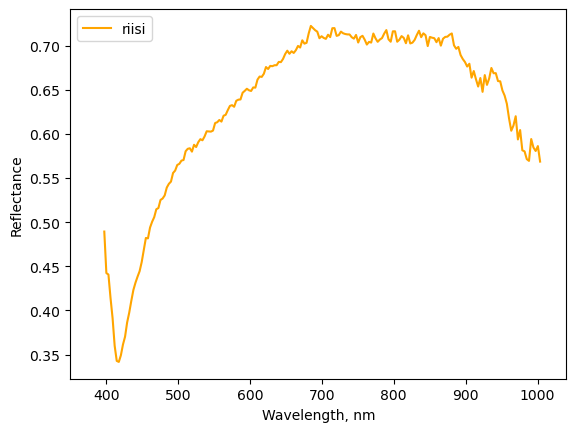

In [4]:
# Defining the path to the necessary image:
path = '/n/archive/labs/hsi-data/everyday_objects/kitchen/'
folder_name1 = 'basmatiriisi'
file_number1 = '040'

# Reading the different spectral bands from an HDR file:
h = envi.read_envi_header(path+folder_name1+'/capture/'+file_number1+'.hdr')['wavelength']
k = []
for i in h:
    k.append(float(i))

# Picking a random pixel:
x = np.random.randint(150, 350)
y = np.random.randint(100, 300)

# Squeezing the pixel to the correct format using the helper functions:
pixel = squeeze(x, y, path, folder_name1, file_number1)

# Plotting the values of the measured spectral bands in the picked pixel:
plt.plot(k, pixel, label = 'riisi', color='orange')
plt.legend(loc='upper left')
plt.xlim(350,1040)
plt.xlabel("Wavelength, nm")
plt.ylabel("Reflectance")
plt.show()

### Preprocessing

The images need to be preprocessed before they can be reliably used in research. A simple way of preprocessing is cropping the photo to reduce the amount of unnecessary data. Like you can see in the above photo, the black background can be cropped a lot. There might also be unintentional noise or offset in the data. This is why the capture folder contains images labelled `WHITEREF_[nr]` and `DARKREF_[nr]`. These images are used to remove the possible noise or offset as thoroughly as possible, and to get an idea of the sensor's sensitivity to light.

<br>

Below are some example images of the bands of the spectral cube.

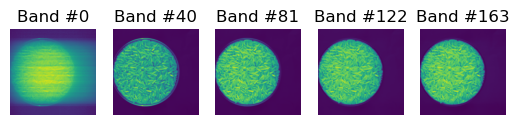

In [25]:
data_raw = spectral.envi.open('/n/archive/labs/hsi-data/everyday_objects/kitchen/basmatiriisi/capture/040.hdr')

cube_raw = np.array(data_raw.asarray())

i = 5

fig, axs = plt.subplots(1, i)

for p in range(0, i):
    axs[p].set_title("Band #" + str(int(p*(204/i))))
    axs[p].imshow(cube_raw[:,:,int(p*(204/i))])
    axs[p].axis('off')

plt.show()

The noise cancellation and offset removal happens by subtracting the dark reference from the raw data and then dividing the result with the raw data subtracted from the white reference.